# 1 - Introduction

Welcome to the [ICR - Identifying Age-Related Conditions](https://www.kaggle.com/competitions/icr-identify-age-related-conditions/overview). The purpose of this notebook is to take a deep dive into the characteristics of the dataset underlying this particular competition. The goal is to provide some high level insights into the nature of the dataset, and then look at individual features. In addition, basic modeling will be performed to determine if any engineered features provide lift to the model, or if there are other aspects of the data that can be exploited. With that said, this particular notebook is broken into two parts:

* Exploratory Data Analysis (EDA) - a walkthrough of various trends and data, along with a summary of key observations from each.
* Empirical Modeling - empirical testing of observations through the use of simple models.

In this competition we are looking at anonymous medical data that can be used to detect one of three different medical conditions. There are two targets we are asking for predictions for:

* Class 0 - none of the three medical conditions exist.
* Class 1 - one of more of the three medical conditions exist.

The submission to the competition is based on the prediction probability of each class. In other words, a probability of the class is required, not the class label itself. Values for each class label will range between 0 and 1. Let's get started!

# 1.1 - Initial Dataset Impressions

Let's look at the memory and disk footprints first, as this can sometimes be a limiting factor on what we can do.

| Dataset | Size on Disk | Size in Memory | # of Rows | # of Cols |
| ------- | ------------ | -------------- | --------- | --------- |
| `train` | 325 KB       | 273 K          | 617       | 58        |
| `test`  | 1.4 KB       | N/A            | 5         | 57        |
| `greeks`| 19 KB        | 28.3 K         | 617       | 6         |

Looking at our `train` dataset, there are 617 rows of data to learn from. This may make this particular competition challenging, as overfit is highly likely. As well, small differences between the `train` and hidden `test` set distributions may have big impacts on our developed models. However, the competition public LB is scored on 48% of the test data, which suggests that the public LB standings may be representative of actual standings at competition close. 

The `test` set does not have any significant amount of data attached to it because this is a code competition. In other words, the `test` data that we have is not representative of the test data that we will get for the competition. The true testing data will remain hidden until we upload a notebook to the Kaggle API and actually have it run for a submission. Until then, the 5 rows we have in the testing data serve as a placeholder to ensure that our prediction methods are working correctly. This means, unfortunately, that analyses such as adversarial validation will be unavailable in this EDA.

Included with this however, is supplemental data contained in the `greeks` dataset. While this information is only available for the test set, it does suggest that there may be opportunity for _soft labeling_. In particular, the competition is asking to predict the probability of one of several age-related conditions, but all three of those conditions are aggregated into a single class label (Class 1). The `greeks` dataset contains the actual age-related condition in the `Alpha` column. We may be able to break out these individual age related condition labels and predict them instead. We can then use the predicted labels as part of another classifier that then attempts to predict the correct probabilities. Similarly, the `Beta`, `Delta`, and `Gamma` columns may contain additional soft-label information we can use as part of a multi-stage classifier.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

train = pd.read_csv("../input/icr-identify-age-related-conditions/train.csv")
test = pd.read_csv("../input/icr-identify-age-related-conditions/test.csv")
greeks = pd.read_csv("../input/icr-identify-age-related-conditions/greeks.csv")

train

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,fd3dafe738fd,0.149555,3130.05946,123.763599,9.513984,13.020852,3.499305,0.077343,8.545512,2.804172,...,0.173229,1.26092,0.067730,8.967128,217.148554,8095.932828,24.640462,69.191944,21.978000,0
613,fd895603f071,0.435846,5462.03438,85.200147,46.551007,15.973224,5.979825,0.025882,12.622906,3.777550,...,10.223150,1.24236,0.426699,35.896418,496.994214,3085.308063,29.648928,124.808872,0.145340,0
614,fd8ef6377f76,0.427300,2459.10720,130.138587,55.355778,10.005552,8.070549,0.025578,15.408390,1.229900,...,0.173229,0.49706,0.067730,19.962092,128.896894,6474.652866,26.166072,119.559420,21.978000,0
615,fe1942975e40,0.363205,1263.53524,85.200147,23.685856,8.138688,7.981959,0.025578,7.524588,1.229900,...,9.256996,0.78764,0.670527,24.594488,72.611063,1965.343176,25.116750,37.155112,0.184622,0


We can also do a quick search to see how many unique values there are for each feature. This will tell us a little bit about the nature of each column (we'll examine this more in depth later when we do a deep dive into actual feature properties).

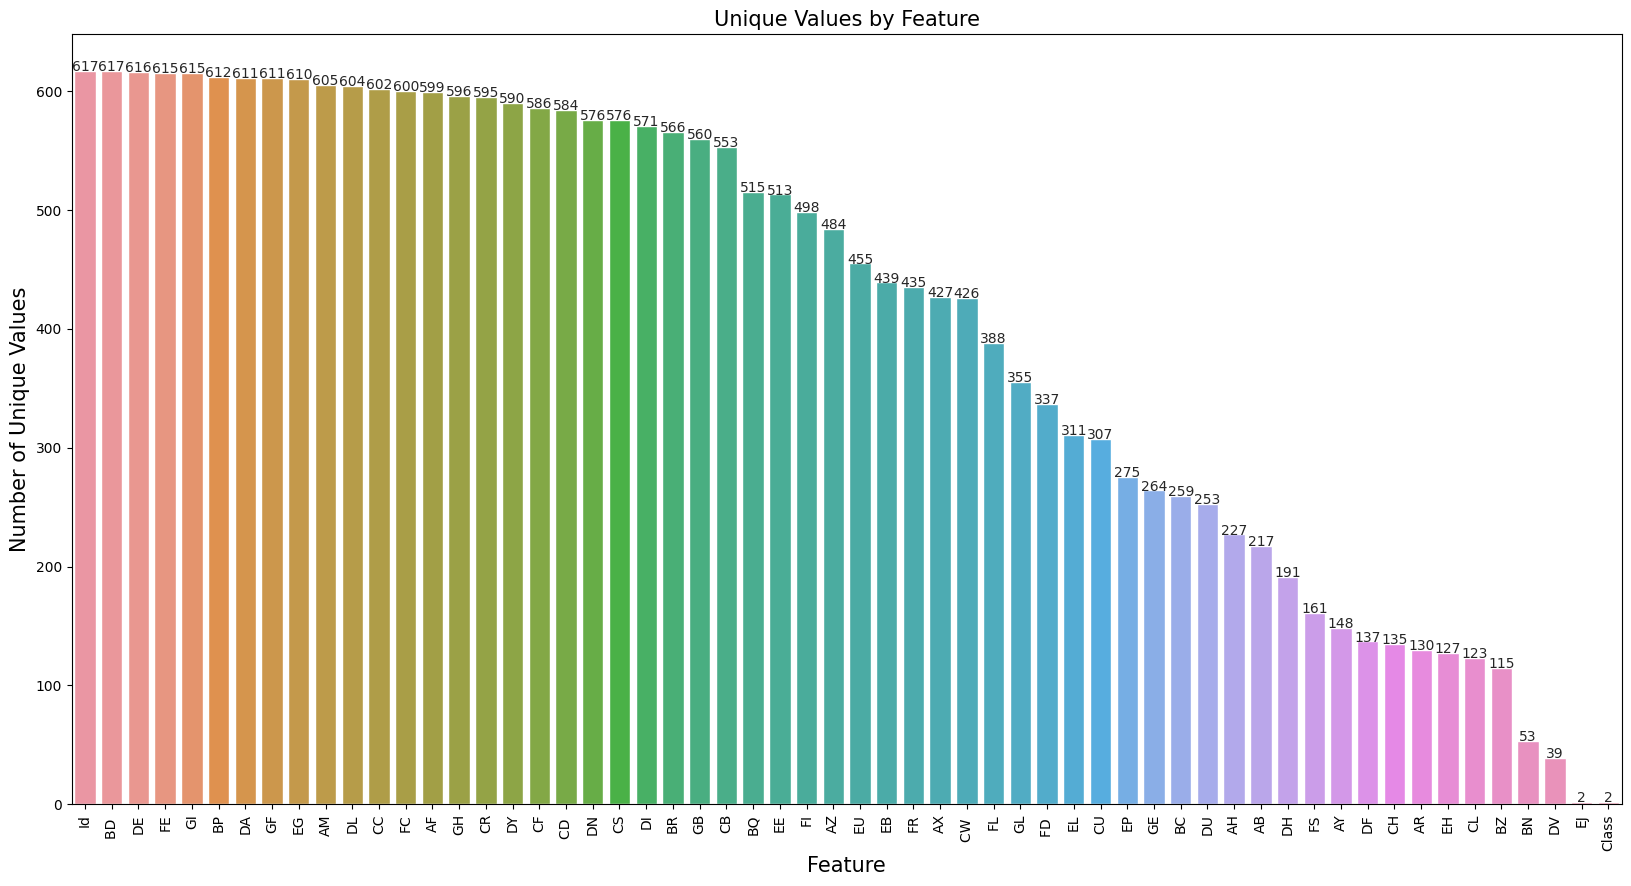

In [2]:
data = {
    "Feature": [],
    "Counts": []
}

for feature in train.columns:
    if feature != "null_count":
        data["Feature"].append(feature)
        data["Counts"].append(train[feature].nunique())

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))

sns.set_style('darkgrid')
sns.set_palette('Set2')

counts = pd.DataFrame(data)
_ = sns.barplot(x=counts.Feature, y=counts.Counts, ax=ax, order=counts.sort_values('Counts', ascending=False).Feature)
for p in ax.patches:
    ax.text(x=p.get_x()+(p.get_width()/2), y=p.get_height(), s="{:,d}".format(round(p.get_height())), ha="center")
_ = ax.set_title("Unique Values by Feature", fontsize=15)
_ = ax.set_ylabel("Number of Unique Values", fontsize=15)
_ = ax.set_xlabel("Feature", fontsize=15)
for label in ax.get_xticklabels():
    label.set_rotation(90)

As expected, the `Class` target is binary, as is `EJ`. However, `BN` and `DV` appear to have smaller number of unique values when compared to the remainder of the features. It could be that these two features are target or count encoded categorical variables. We'll have to examine them more closely when we look at individual features.

Let's look at the test set.

In [3]:
test

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,00eed32682bb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,010ebe33f668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,02fa521e1838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,040e15f562a2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,046e85c7cc7f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The test set only contains 5 rows, and all values are zero. This is expected, as the competition is keeping the test set private. Only submitted notebooks will have access to the actual test data.

Let's look at the supplemental data.

In [4]:
greeks

,Id,Alpha,Beta,Gamma,Delta,Epsilon
0,000ff2bfdfe9,B,C,G,D,3/19/2019
1,007255e47698,A,C,M,B,Unknown
2,013f2bd269f5,A,C,M,B,Unknown
3,043ac50845d5,A,C,M,B,Unknown
4,044fb8a146ec,D,B,F,B,3/25/2020
...,...,...,...,...,...,...
612,fd3dafe738fd,A,B,M,B,9/13/2020
613,fd895603f071,A,B,M,B,9/8/2020
614,fd8ef6377f76,A,C,M,B,7/24/2019
615,fe1942975e40,A,C,M,B,1/31/2019


Again, we can check to see unique values.

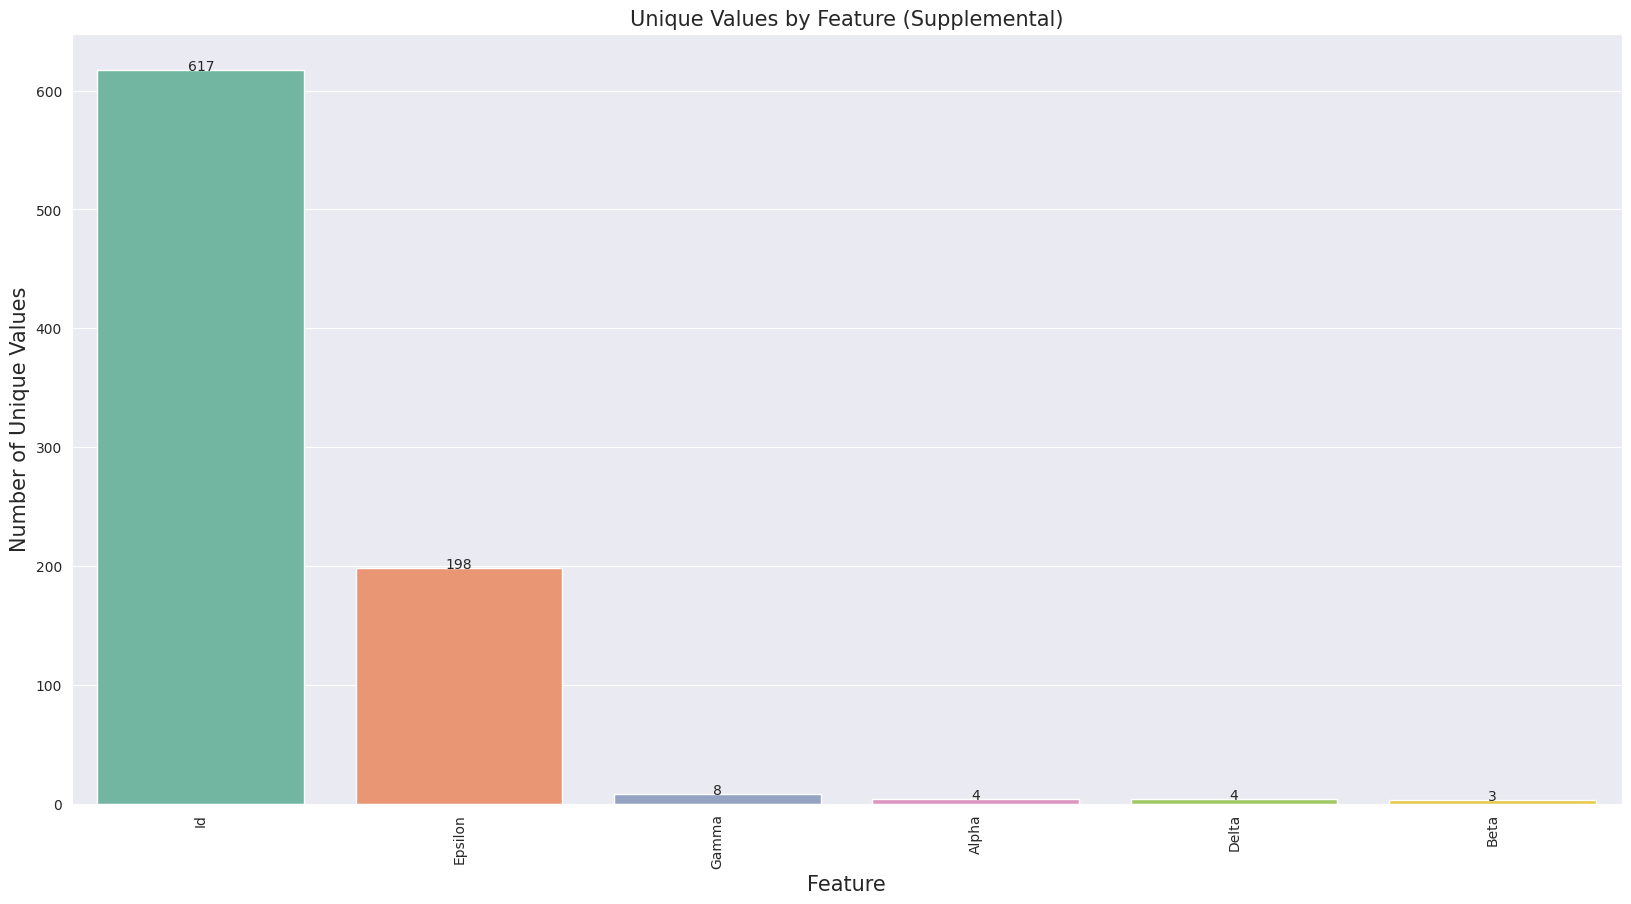

In [5]:
data = {
    "Feature": [],
    "Counts": []
}

for feature in greeks.columns:
    if feature != "null_count":
        data["Feature"].append(feature)
        data["Counts"].append(greeks[feature].nunique())

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))

sns.set_style('darkgrid')
sns.set_palette('Set2')

counts = pd.DataFrame(data)
_ = sns.barplot(x=counts.Feature, y=counts.Counts, ax=ax, order=counts.sort_values('Counts', ascending=False).Feature)
for p in ax.patches:
    ax.text(x=p.get_x()+(p.get_width()/2), y=p.get_height(), s="{:,d}".format(round(p.get_height())), ha="center")
_ = ax.set_title("Unique Values by Feature (Supplemental)", fontsize=15)
_ = ax.set_ylabel("Number of Unique Values", fontsize=15)
_ = ax.set_xlabel("Feature", fontsize=15)
for label in ax.get_xticklabels():
    label.set_rotation(90)

We should also make sure to check that all of the `Id` values in `greeks` match up with those in `train`.

In [6]:
greek_ids = set(greeks["Id"].tolist())
train_ids = set(train["Id"].tolist())

if len(greek_ids) != len(train_ids):
    print("! greek and train identifiers not the same size")
else:
    print(": greek and train identifiers are the same size")

if (greek_ids - train_ids) == set():
    print(": greek and train identifiers map to each other")
else:
    print("! greek and train identifiers do not map to each other")

: greek and train identifiers are the same size
: greek and train identifiers map to each other


### Key Observations about Initial Impressions

* The memory and disk sizes for the `train` and `greeks` datasets are small- this means that we likely won't be facing too much memory pressure.
    * This is good news, since the Kaggle VMs are limited to 16 GB of RAM.
* For our `test` set, we have only 5 rows, with 0.0 values for each feature.
    * This is expected, since the actual test set will remain hidden until the notebook is run for the actual submission.
* For our `train` set:
    * There are 617 unique `Id` values.
    * For the individual features, we have a mixture of what may appear to be categorical and continuous values:
        * The `EJ` feature is binary in nature
        * Both `BN` and `DV` have relatively small numbers of unique values, suggesting the potential for a categorical feature that may be target encoded in some fashion.
* For our `greeks` set:
    * There are 617 unique `Id` values, each of which maps to an identifier in the `train` set
    * There appear to be 4 categorical features:
        * `Alpha`, `Beta`, `Gamma`, `Delta`
    * There are numerous `Unknown` values in the `Epsilon` columns, otherwise they contain date values as strings

# 1.2 - Class Balance

Given that we are predicting classes, we should look to see if there is significant class skew.

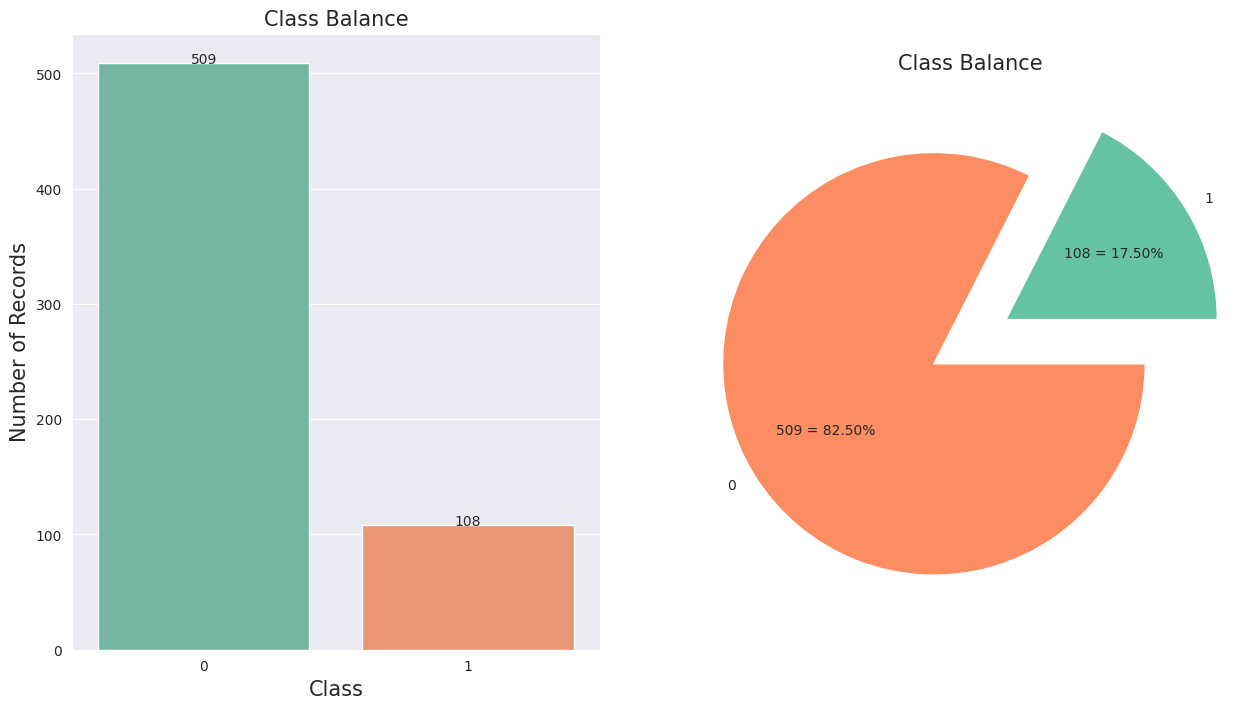

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

sns.set_style('darkgrid')
sns.set_palette('Set2')

counts = pd.DataFrame(train["Class"].value_counts())
_ = sns.barplot(x=counts.index, y=counts.Class, ax=axs[0])
for p in axs[0].patches:
    axs[0].text(x=p.get_x()+(p.get_width()/2), y=p.get_height(), s="{:,d}".format(round(p.get_height())), ha="center")
_ = axs[0].set_title("Class Balance", fontsize=15)
_ = axs[0].set_ylabel("Number of Records", fontsize=15)
_ = axs[0].set_xlabel("Class", fontsize=15)

targets = train["Class"].unique()
data = [train[(train["Class"] == target)]["Id"].count() for target in targets]
_ = axs[1].pie(
    data, labels=targets,
    autopct=lambda x: "{:,.0f} = {:.2f}%".format(x * sum(data)/100, x),
    explode=[0.20] * len(data), 
    colors=sns.color_palette("Set2")[0:len(data)],
)
_ = axs[1].set_title("Class Balance", fontsize=15)

As we can see, there is a fairly significant class skew. The training data appears to be mostly comprised of Class 0 examples, with only about 18% of the data making up Class 1 examples. Given that we have some supplemental data contained within the `greeks` dataset, we should check to see what the `Alpha` targets look like as well, as these directly relate to the actual Class 1 labels.

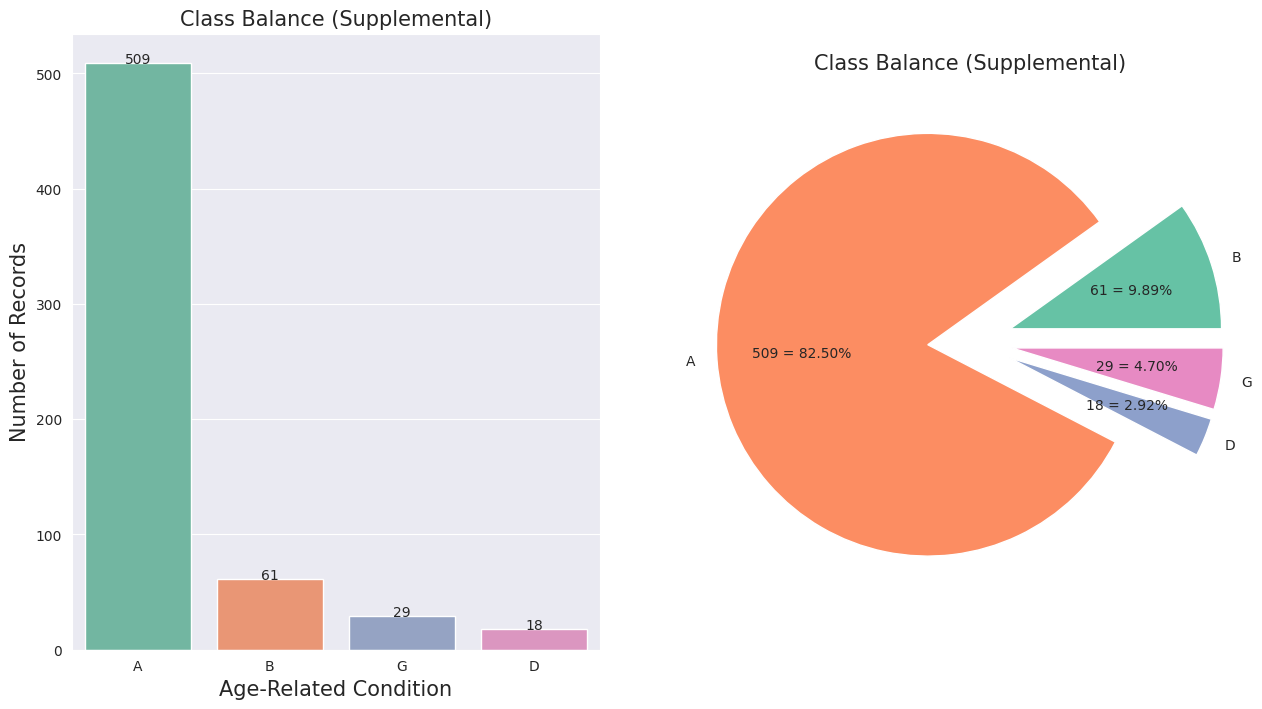

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

sns.set_style('darkgrid')
sns.set_palette('Set2')

counts = pd.DataFrame(greeks["Alpha"].value_counts())
_ = sns.barplot(x=counts.index, y=counts.Alpha, ax=axs[0])
for p in axs[0].patches:
    axs[0].text(x=p.get_x()+(p.get_width()/2), y=p.get_height(), s="{:,d}".format(round(p.get_height())), ha="center")
_ = axs[0].set_title("Class Balance (Supplemental)", fontsize=15)
_ = axs[0].set_ylabel("Number of Records", fontsize=15)
_ = axs[0].set_xlabel("Age-Related Condition", fontsize=15)

targets = greeks["Alpha"].unique()
data = [greeks[(greeks["Alpha"] == target)]["Id"].count() for target in targets]
_ = axs[1].pie(
    data, labels=targets,
    autopct=lambda x: "{:,.0f} = {:.2f}%".format(x * sum(data)/100, x),
    explode=[0.20] * len(data), 
    colors=sns.color_palette("Set2")[0:len(data)],
)
_ = axs[1].set_title("Class Balance (Supplemental)", fontsize=15)

As we can see, the actual age-related conditions are rare, with condition `D` being the most rare class of condition. 

### Key Observations about Class Balance

* The training dataset is imbalanced:
    * 82.5% of the data falls under Class 0
    * 17.5% of the data falls under Class 1
* The supplemental dataset is similarly unbalanced:
    * 82.5% of the data falls under `A` (Class 0)
    * 17.5% of the data falls under the following age related categories (Class 1):
        * 9.89% of the data is under `B`
        * 4.70% of the data is under `G`
        * 2.92% of the data is under `D`

# 1.3 - Null Values

We should check to see if we have missing or null values in our data and supplemental data.

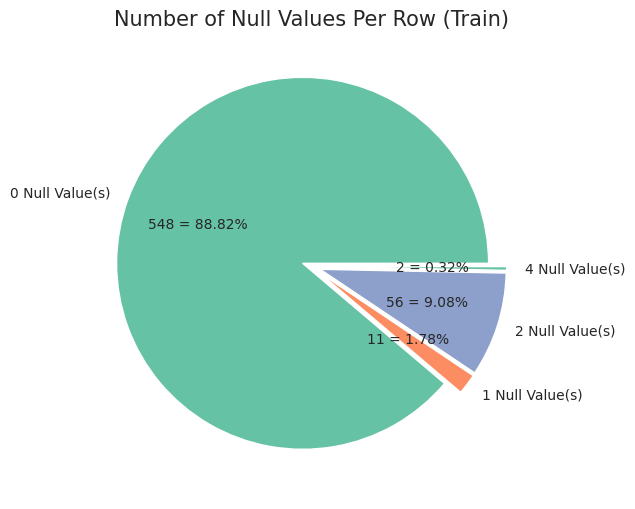

In [9]:
train["null_count"] = train.isnull().sum(axis=1)
counts = train.groupby("null_count")["Id"].count().to_dict()
null_data = {"{} Null Value(s)".format(k) : v for k, v in counts.items() if k < 8}

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 7))

_ = axs.pie(
    x=list(null_data.values()), 
    autopct=lambda x: "{:,.0f} = {:.2f}%".format(x * sum(null_data.values())/100, x),
    explode=[0.05] * len(null_data.keys()), 
    labels=null_data.keys(), 
    colors=sns.color_palette("Set2")[0:3],
)
_ = axs.set_title("Number of Null Values Per Row (Train)", fontsize=15)

There are some rows that have missing data. What we should do is check to see if we have a systematic problem with representation. In other words, are there any particular columns that systematically have null values, or are the columns at random.

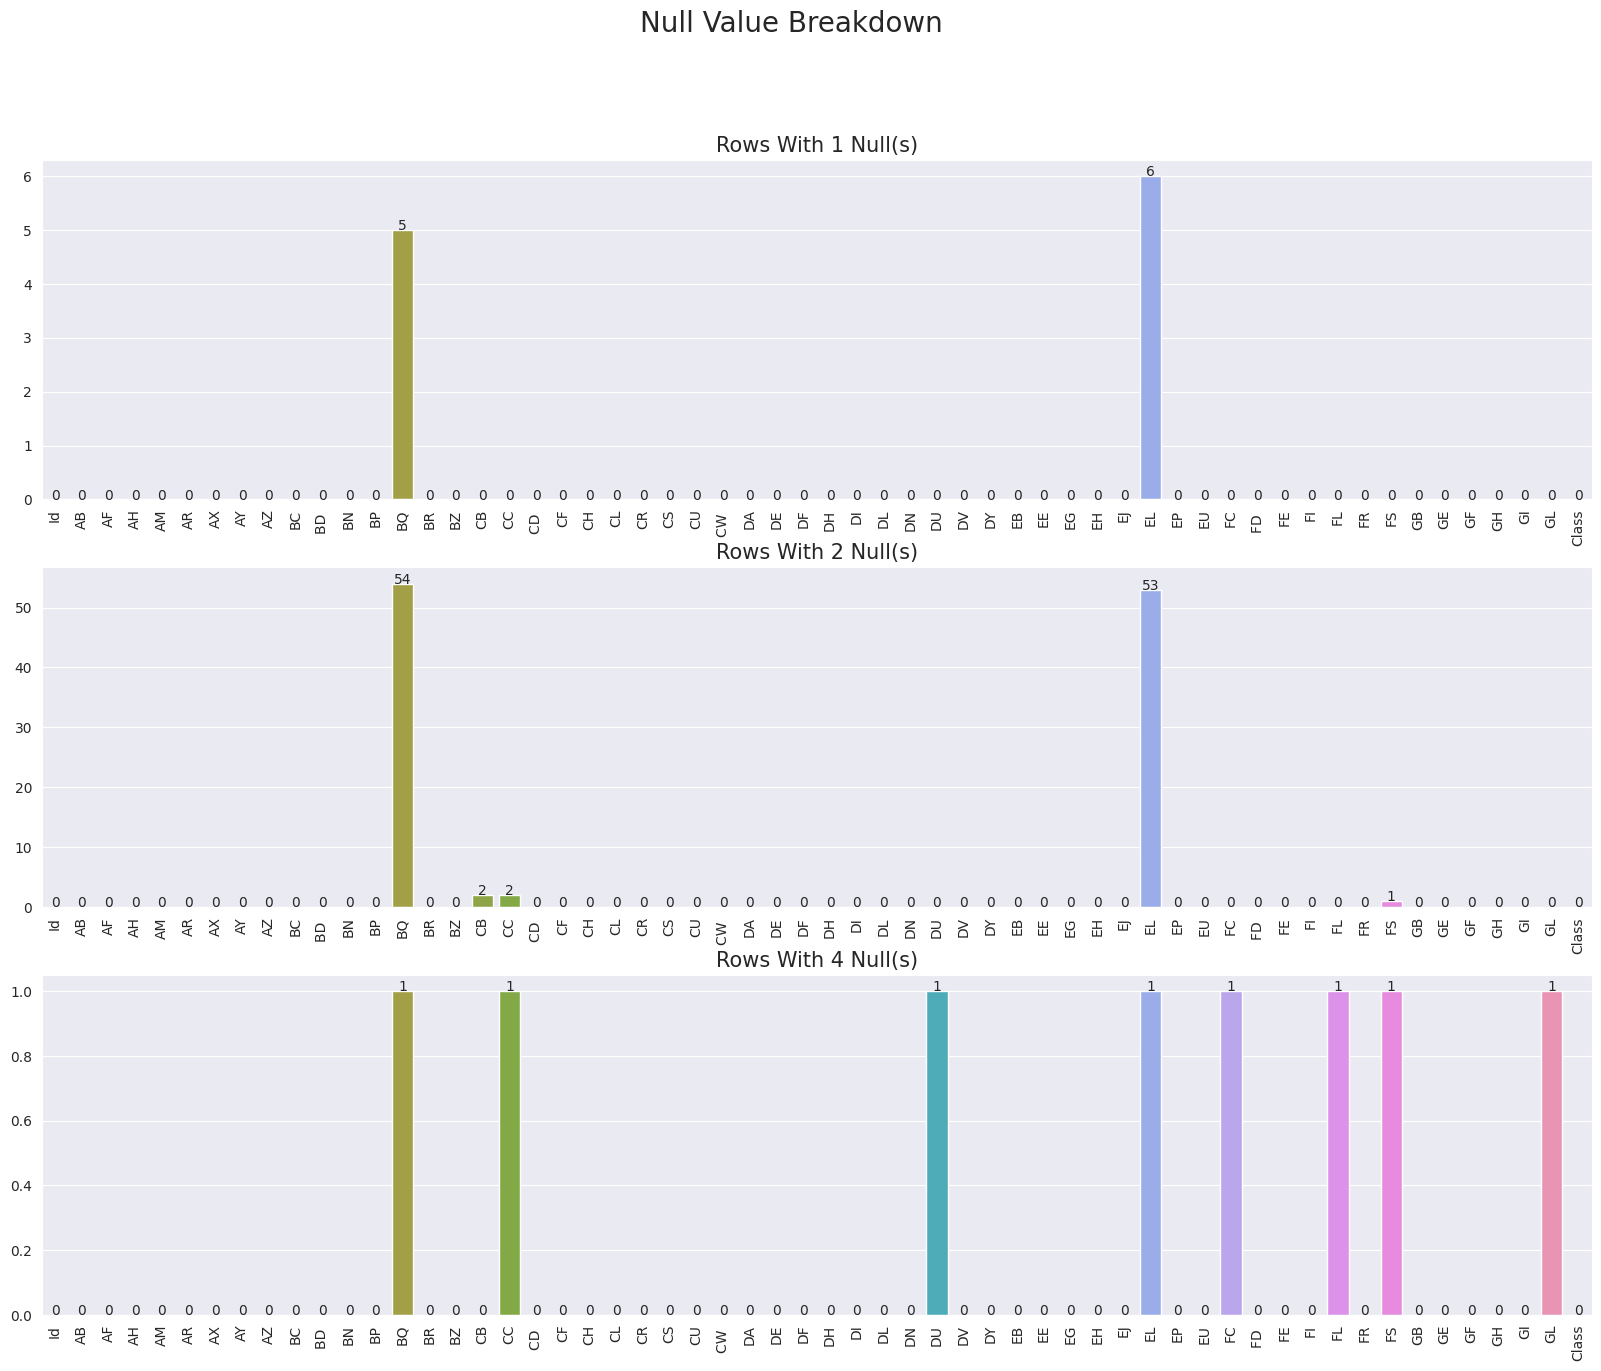

In [10]:
null_count_labels = [train[(train["null_count"] == x)].isnull().sum().index[:-1] for x in [1, 2, 4]]
null_count_values = [train[(train["null_count"] == x)].isnull().sum().values[:-1] for x in [1, 2, 4]]
null_count_numbers = [1, 2, 4]

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 15))
fig.suptitle("Null Value Breakdown", fontsize=20)

axs = axs.flatten()
axis_counter = 0

for null_labels, null_values, null_numbers in zip(null_count_labels, null_count_values, null_count_numbers):
    ax = axs[axis_counter]
    _ = sns.barplot(x=null_labels, y=null_values, ax=ax)
    _ = ax.set_title("Rows With {} Null(s)".format(null_numbers), fontsize=15)
    _ = ax.set_ylabel("")
    _ = ax.set_xlabel("")
    _ = ax.set_xticks([z for z in range(len(null_labels))], null_labels, rotation=90)
    for p in ax.patches:
        height = p.get_height()
        ax.text(x=p.get_x()+(p.get_width()/2), y=height, s="{:d}".format(int(height)), ha="center")
    axis_counter += 1

The biggest problem with null values appears to be in the `BQ` and `EL` features. If a row has any null value, the highest likelyhood is that the null is in the `BQ` or `EL` feature singularly, or `BQ` and `EL` features together. We will have to examine the impact of the null value later on in the feature exploration column. In particular, we can attempt to impute the missing value, or we can see if the missing value itself is meaningful. While we are at it, we should also examine the supplemental data as well.

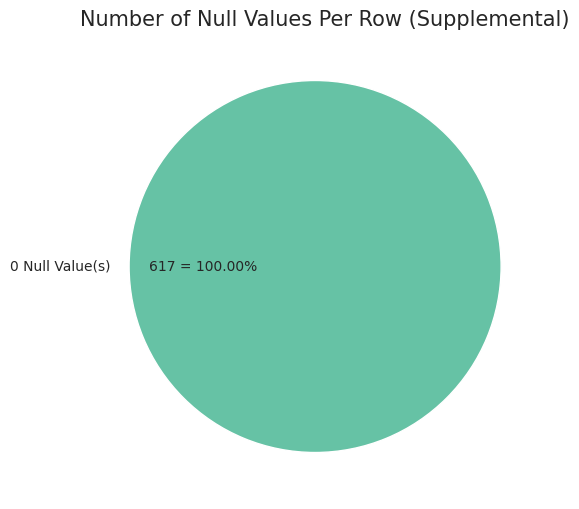

In [11]:
greeks["null_count"] = greeks.isnull().sum(axis=1)
counts = greeks.groupby("null_count")["Id"].count().to_dict()
null_data = {"{} Null Value(s)".format(k) : v for k, v in counts.items() if k < 8}

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 7))

_ = axs.pie(
    x=list(null_data.values()), 
    autopct=lambda x: "{:,.0f} = {:.2f}%".format(x * sum(null_data.values())/100, x),
    explode=[0.05] * len(null_data.keys()), 
    labels=null_data.keys(), 
    colors=sns.color_palette("Set2")[0:3],
)
_ = axs.set_title("Number of Null Values Per Row (Supplemental)", fontsize=15)

None of the supplemental data has missing information.

### Key Observations about Null Values

* There appear to be null values in 11% of the training data.
    * Nulls are likely to appear in the `BQ` and `EL` features, either singularly or, most often, together at the same time.
    * We will explore whether we should impute missing values, keep them, or drop the features in the feature exploration section below.
* There are no null values in the supplemental data.

# 1.3 - Duplicated Rows

We should next check to see if we have any duplicated values in our various datasets. Duplicates may impact our learning methods, resulting in prediction bias toward the duplicate information. 

In [12]:
duplicates = train.pivot_table(index=[
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL'
], aggfunc="size")
unique, counts = np.unique(duplicates, return_counts=True)
value_counts = dict(zip(unique, counts))

if len(unique) == 1:
    print(": There are no duplicated rows in the training set")
else:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 8))

    _ = sns.barplot(x=list(value_counts.keys())[1:], y=list(value_counts.values())[1:], ax=ax)
    _ = ax.set_title("Duplicate Counts in Training Set", fontsize=15)
    _ = ax.set_ylabel("Count")
    _ = ax.set_xlabel("Number of Times Row is Duplicated")
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x()+(p.get_width()/2),
            y=height,
            s="{:d}".format(int(height)),
            ha="center"
        )

: There are no duplicated rows in the training set


### Key Observations about Duplicated Rows

* There appear to be no duplicated rows in the training set.

# 1.4 - Statistical Breakdown

Let's look at some high-level statistics about the training data. Specifically, what we are looking for are instances where the max or min values are much higher or lower than the mean when taking the standard deviation into account. In other words, we're looking for features that appear to have large outliers.

In [13]:
features = [
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL'
]

train[features].describe().T.style.bar(subset=['mean'], color='#7BCC70')\
    .background_gradient(subset=['std'], cmap='Reds')\
    .background_gradient(subset=['50%'], cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,max
AB,617.000000,0.477149,0.468388,0.081187,0.252107,0.354659,0.559763,6.161666
AF,617.000000,3502.013221,2300.322717,192.593280,2197.345480,3120.318960,4361.637390,28688.187660
AH,617.000000,118.624513,127.838950,85.200147,85.200147,85.200147,113.739540,1910.123198
AM,617.000000,38.968552,69.728226,3.177522,12.270314,20.533110,39.139886,630.518230
AR,617.000000,10.128242,10.518877,8.138688,8.138688,8.138688,8.138688,178.943634
AX,617.000000,5.545576,2.551696,0.699861,4.128294,5.031912,6.431634,38.270880
AY,617.000000,0.060320,0.416817,0.025578,0.025578,0.025578,0.036845,10.315851
AZ,617.000000,10.566447,4.350645,3.396778,8.129580,10.461320,12.969516,38.971568
BC,617.000000,8.053012,65.166943,1.229900,1.229900,1.229900,5.081244,1463.693448
BD,617.000000,5350.388655,3021.326641,1693.624320,4155.702870,4997.960730,6035.885700,53060.599240


As we can see above, there are several instances where we have large outliers. For example, the `AB` feature has a mean of 0.35 and a standard deviation of 0.47. This suggests that most values will fall around 3.5 +- 0.47. However, we see the max value is 6.16, which is many standard deviations away from the mean. This suggests there are outlier values. We can see this if we were to plot the kernel density estimates for each feature. The KDEs will have long tails if there are a few outliers that have abnormally large or small values.

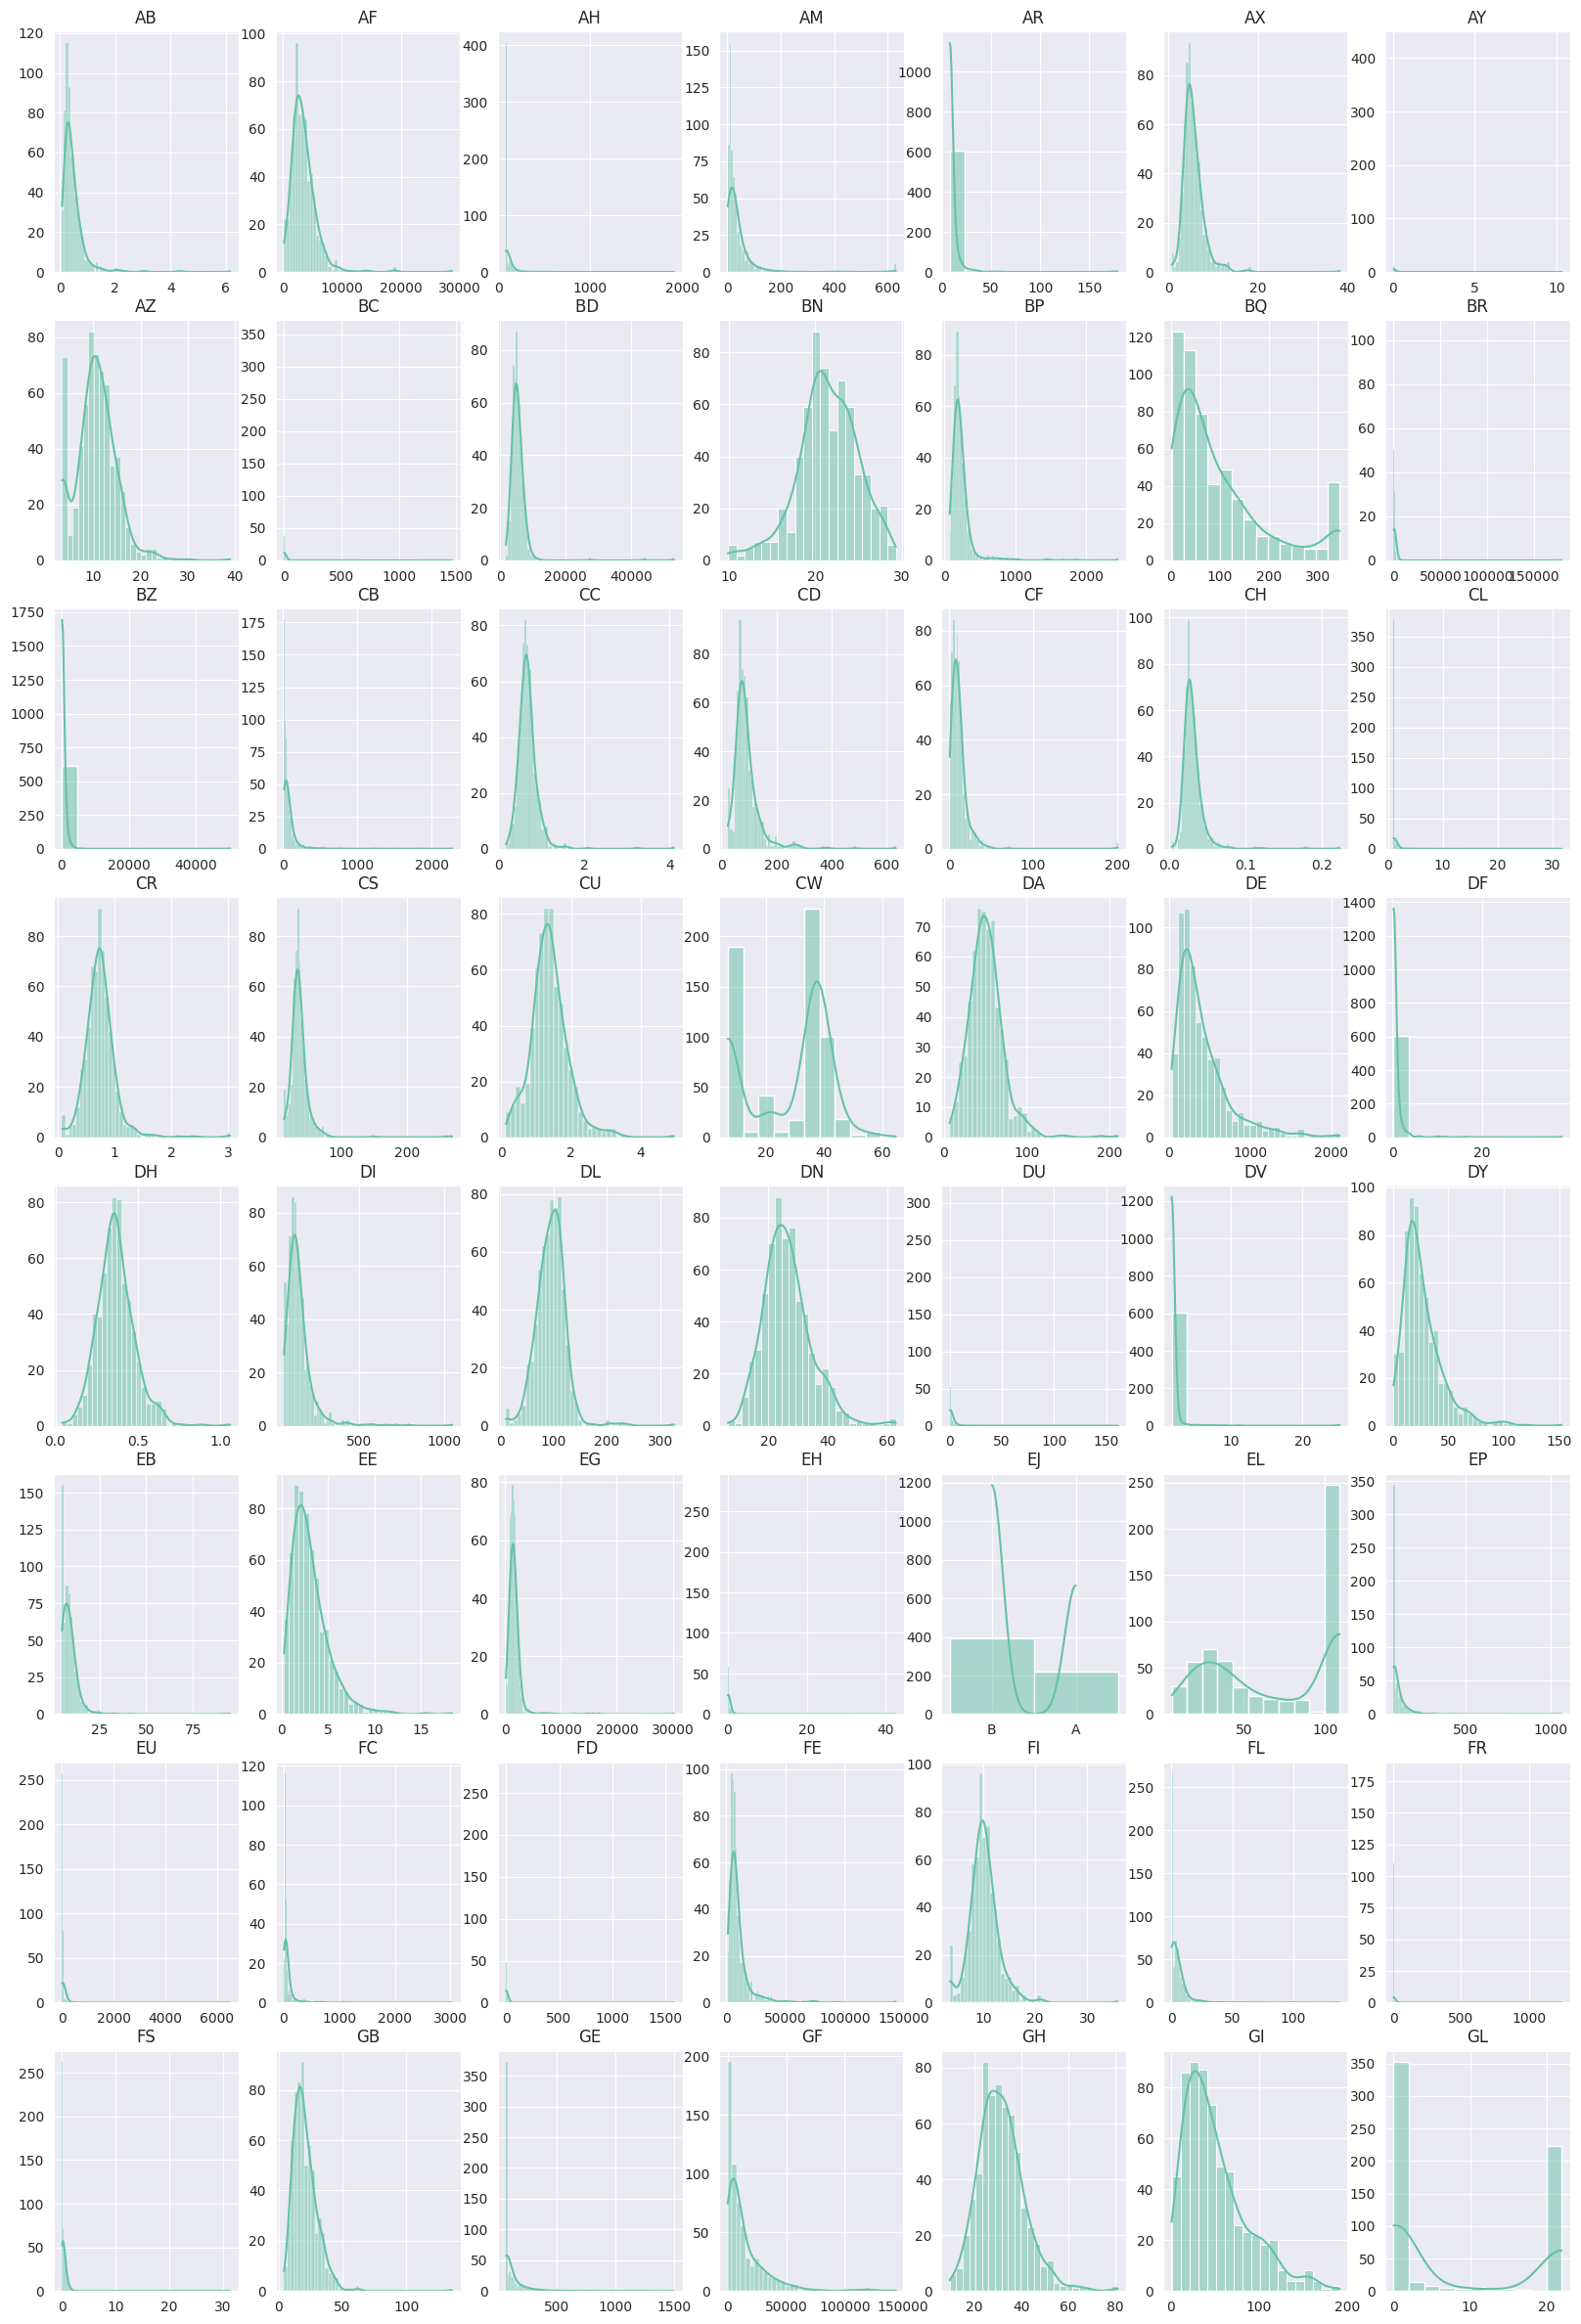

In [14]:
features = [
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL'
]

fig, axs = plt.subplots(nrows=8, ncols=7, figsize=(20, 30))

axs = axs.flatten()

sns.set_style('darkgrid')

axis_counter = 0
for feature in features:
    ax = axs[axis_counter]
    _ = sns.histplot(data=train, x=feature, kde=True, ax=ax)
    _ = ax.set_title("{}".format(feature))
    _ = ax.set_ylabel("")
    _ = ax.set_xlabel("")
    axis_counter += 1

Violin plots will also show us the same outliers, but will give us a better sense of density.

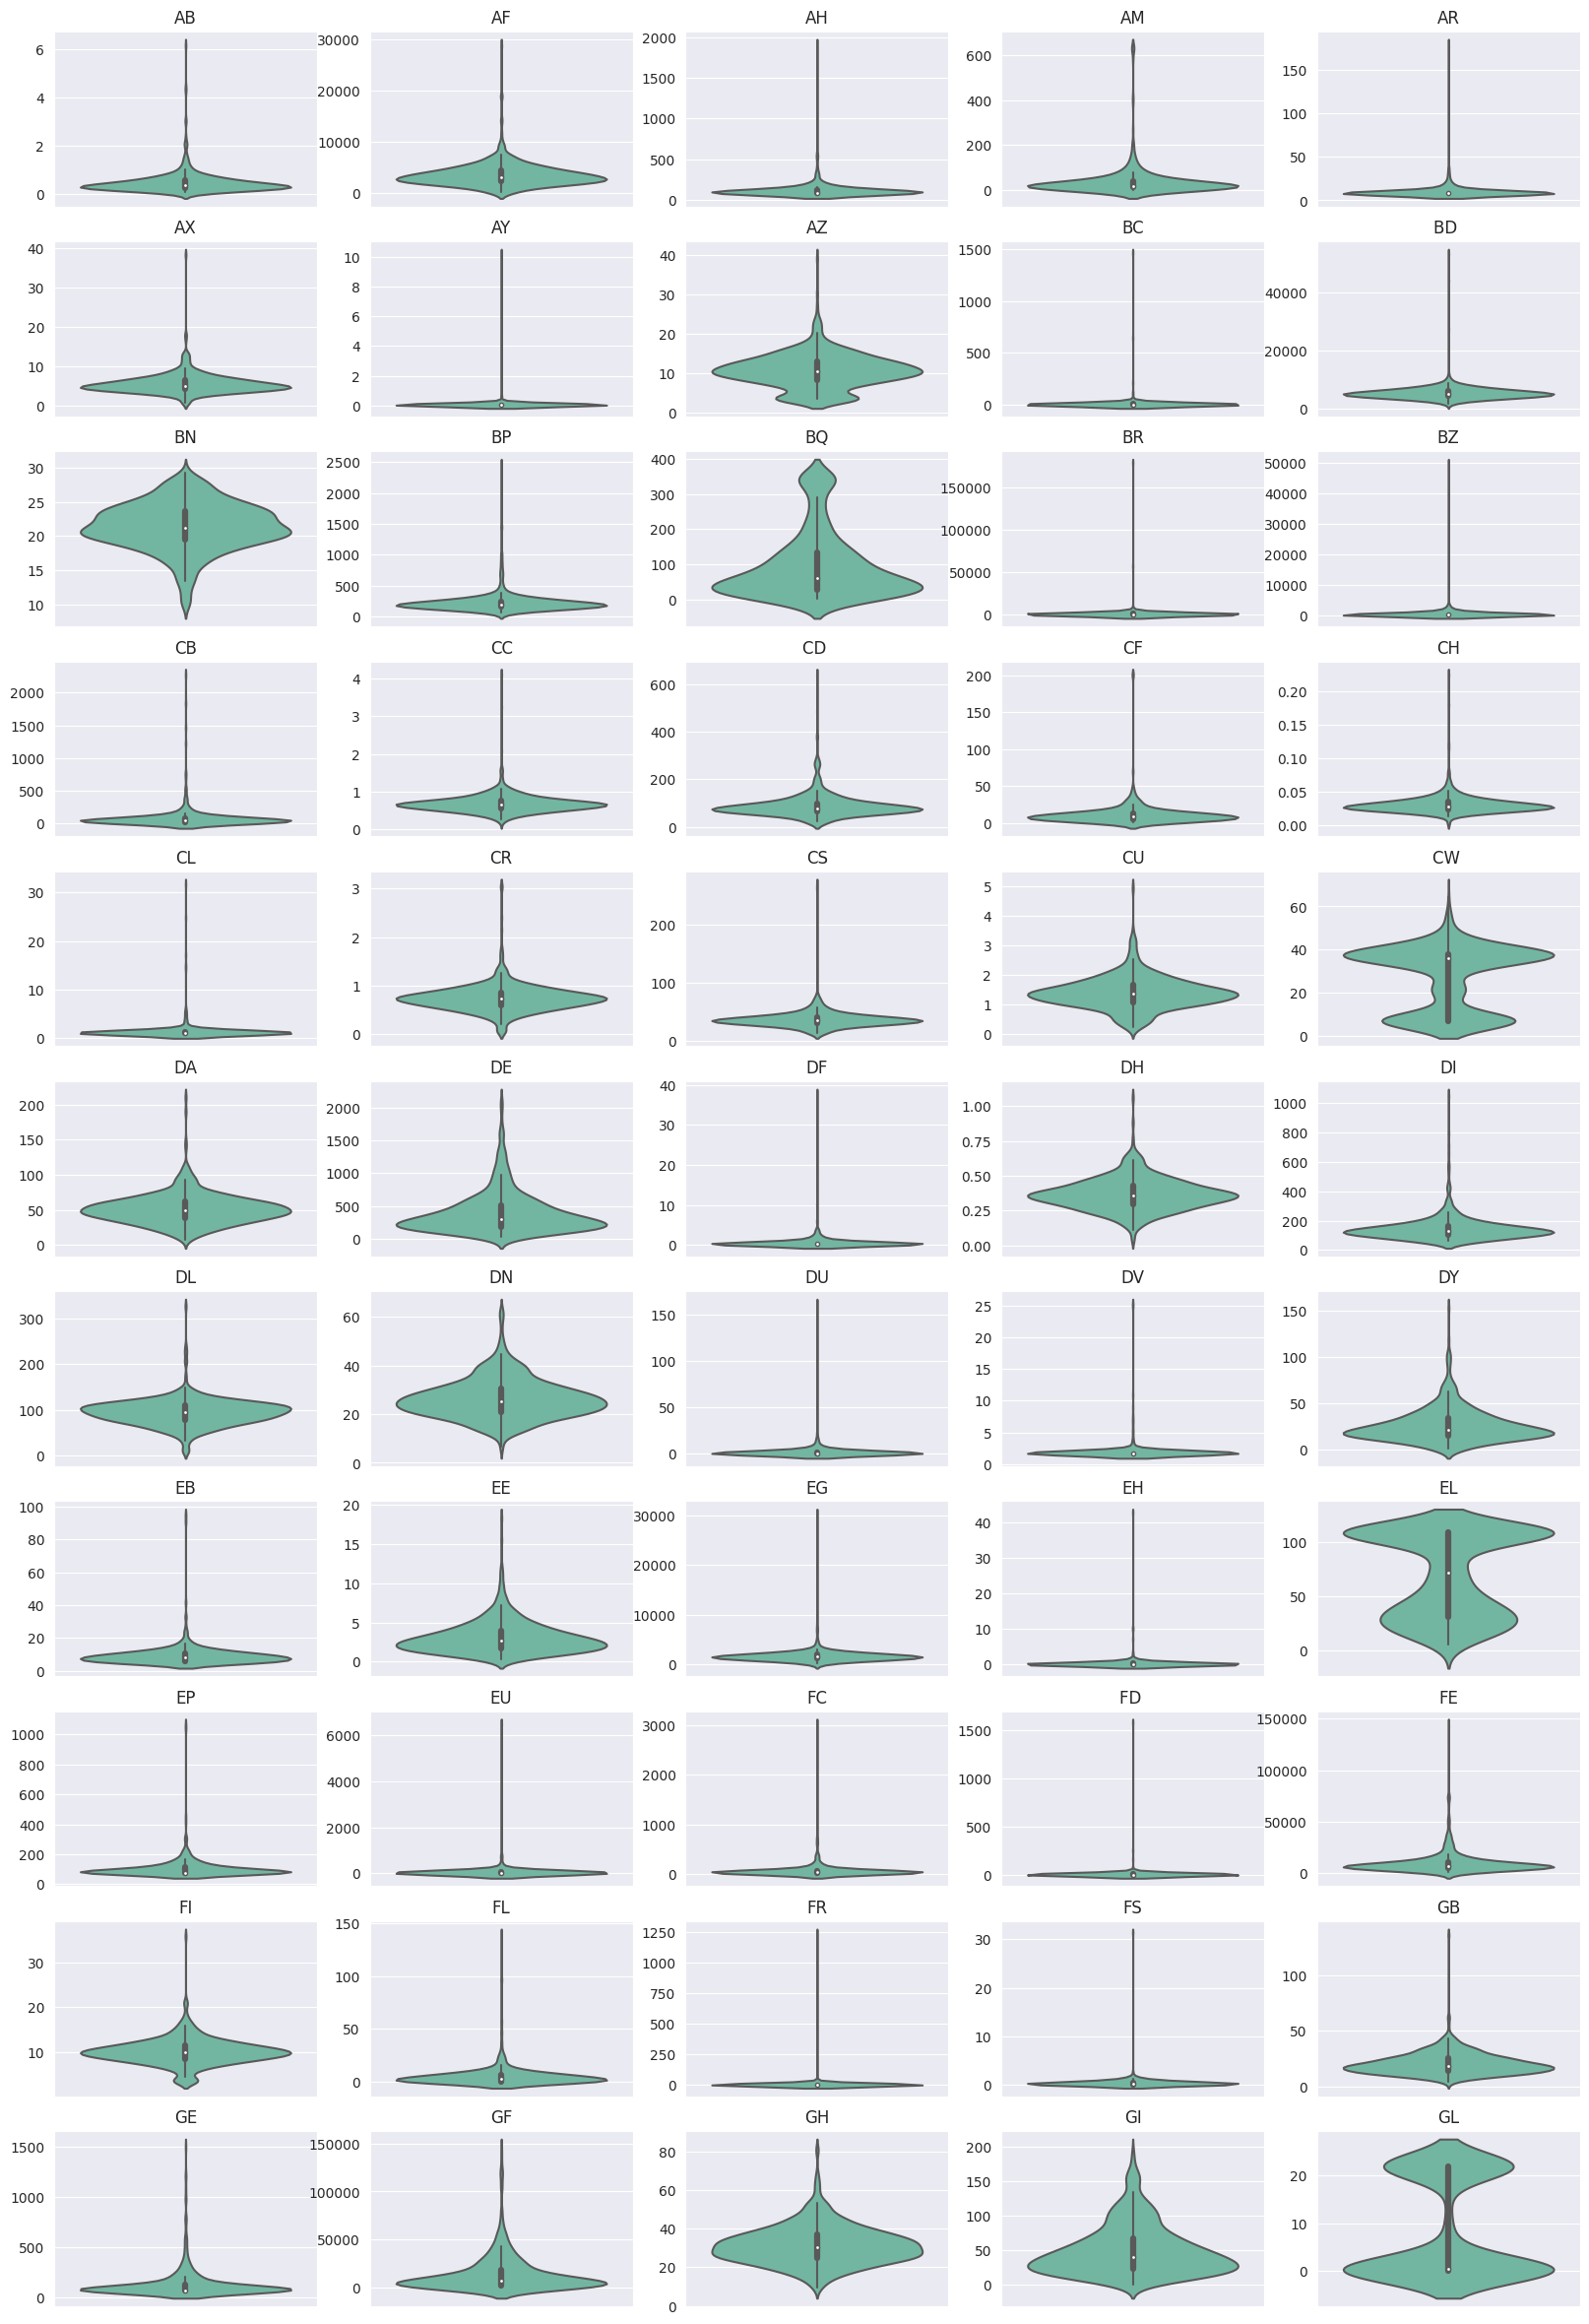

In [15]:
features = [
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL'
]

fig, axs = plt.subplots(nrows=11, ncols=5, figsize=(20, 30))

axs = axs.flatten()

sns.set_style('darkgrid')

axis_counter = 0
for feature in features:
    ax = axs[axis_counter]
    _ = sns.violinplot(y=train[feature], ax=ax)
    _ = ax.set_title("{}".format(feature))
    _ = ax.set_ylabel("")
    _ = ax.set_xlabel("")
    axis_counter += 1

With the violin plots, we're interested in whether there are very long, thin tails. As we can see, features such as `GH` and `GI` have the bulk of their distributions near 0, but have very long tails. This likely means we have outliers that we need to deal with in some way. The outliers may be 

### Key Observations about Statistical Breakdown

* Quite a number of features have outliers that appear well beyond the standard deviation. Examples include:
    * `AF`
    * `AH`
    * `AM`
    * `AR`
    * `BC`
    * `BD`
    * `BP`
* We should check to see if outliers have a higher correlation with one class or another. If so, we can exploit them.

# 1.5 - Spearman Correlation

We should check to see if there is high correlation between our features. Spearman correlation does not make assumptions about distribution types or linearity. With Spearman correlation, we have values that range from -1 to +1. Values around either extreme end mean a negative or positive correlation respectively, while those around 0 mean no correlation exists.

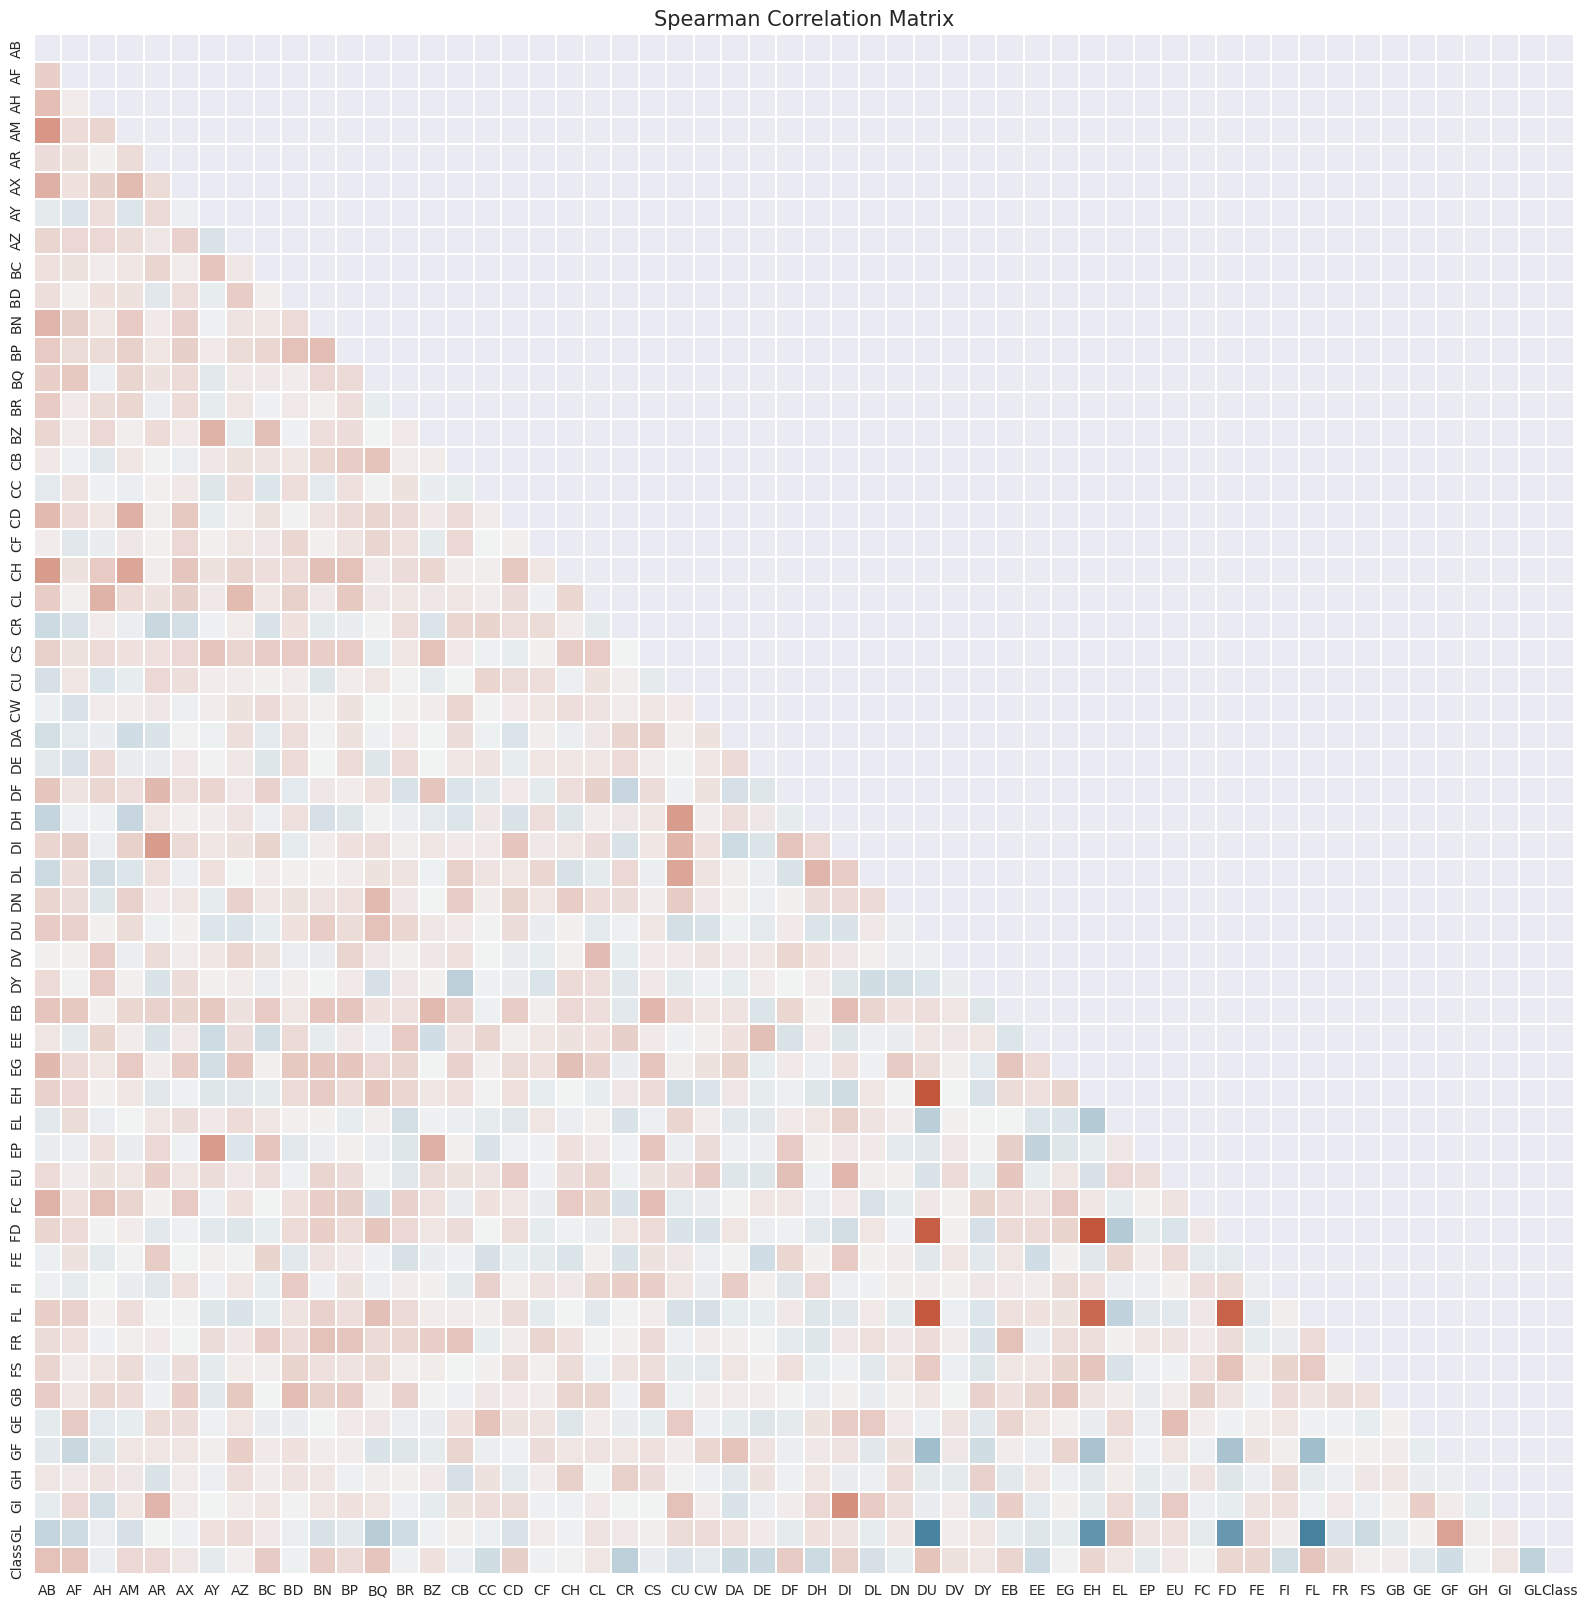

In [16]:
features = [
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL', 'Class'
]

correlation_matrix = train[features].corr(method="spearman")

from matplotlib.colors import SymLogNorm

f, ax = plt.subplots(figsize=(20, 20))
_ = sns.heatmap(
    correlation_matrix, 
    mask=np.triu(np.ones_like(correlation_matrix, dtype=bool)), 
    cmap=sns.diverging_palette(230, 20, as_cmap=True), 
    center=0,
    square=True, 
    linewidths=.1, 
    cbar=False,
    ax=ax,
    annot=False,
)
_ = ax.set_title("Spearman Correlation Matrix", fontsize=15)

The numeric values regarding correlation coefficients aren't shown due to the sheer number of features. However, the depth of their color represents how strong the correlation is. Dark red means strong positive correlation, while dark blue means strong negative correlation. We can see here that no single feature is strongly correlated with the `Class` target. However, there are other features which appear to be very strongly correlated with one another.

### Key Observations about Spearman Correlation

* No single feature shares a strong correlation with the `Class` target.
* There are several features which are strongly correlated with one another. These feature correlations need to be examined in greater detail to see if they can be combined or removed for better classifier performance.

# 1.6 - P-Value Testing

While looking at features visually will tell us some interesting information, we can also use p-value testing to see if a feature has a net impact on a simple regression model. This method is controversial in that it likely doesn't provide a correct look at what features are informative. Our null hypothesis is that the feature impacts the target variable of `Class`. In this case, anything with a p-value greater than 0.05 means we reject that hypothesis, and can potentially flag it for removal. 

In [17]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

features = [
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL', 'Class'
]

train_copy = train.copy()
train_copy.fillna(0.0, inplace=True)

x = add_constant(train_copy[features])
model = OLS(train_copy["Class"], x).fit()

pvalues = pd.DataFrame(model.pvalues)
pvalues.reset_index(inplace=True)
pvalues.rename(columns={0: "pvalue", "index": "feature"}, inplace=True)
pvalues.style.background_gradient(cmap='YlOrRd')

,feature,pvalue
0,const,0.998514
1,AB,0.997198
2,AF,0.597541
3,AH,0.905348
4,AM,0.980763
5,AR,0.983930
6,AX,0.993696
7,AY,1.000000
8,AZ,0.993838
9,BC,0.960578


The results are somewhat surprising. P-Value tests suggest that of all the features available, only `FE` and `GF` have an impact on our target variable. This is somewhat intriguing, as it suggests many of the features we see are somewhat irrelevant. We can run a quick empirical test to see if this holds true or not. We can use LightGBM to build us a model, and measure it's AUC ROC. We'll start using all of the features available to us.

-------> Fold 1 <--------
: AUC ROC = 0.9893048128342247
-------> Fold 2 <--------
: AUC ROC = 0.9795008912655971
-------> Fold 3 <--------
: AUC ROC = 0.9747974797479748
-------> Fold 4 <--------
: AUC ROC = 0.9789915966386555
-------> Fold 5 <--------
: AUC ROC = 0.964985994397759
--> Overall results for out of fold predictions
: AUC ROC = 0.9698755730189915


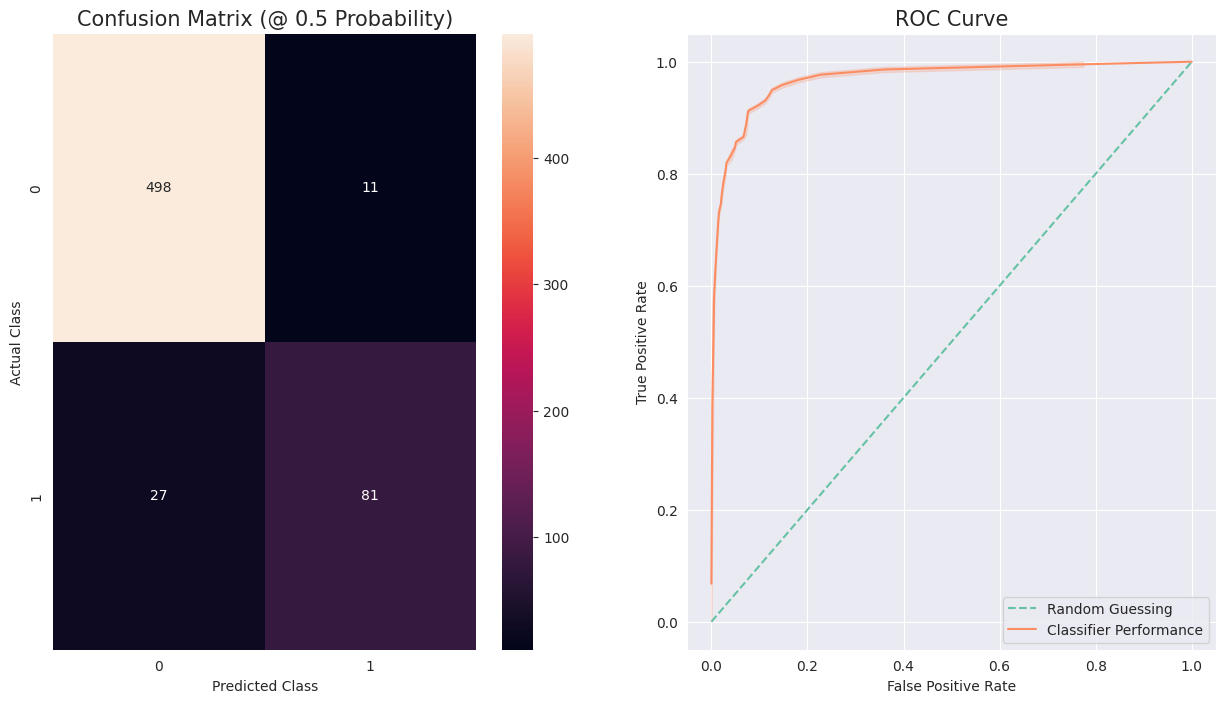

In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

features = [
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL',
]

train_copy = train.copy()

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, random_state=2023, shuffle=True)
train_oof_preds = np.zeros((train_copy.shape[0],))
train_oof_probas = np.zeros((train_copy.shape[0],))

le = LabelEncoder()
train_copy["EJ"] = le.fit_transform(train_copy["EJ"])

for fold, (train_index, test_index) in enumerate(skf.split(train_copy, train_copy["Class"])):
    print("-------> Fold {} <--------".format(fold + 1))
    x_train, x_valid = pd.DataFrame(train_copy.iloc[train_index]), pd.DataFrame(train_copy.iloc[test_index])
    y_train, y_valid = train_copy["Class"].iloc[train_index], train_copy["Class"].iloc[test_index]
    
    x_train_features = pd.DataFrame(x_train[features])
    x_valid_features = pd.DataFrame(x_valid[features])

    model = LGBMClassifier(
        random_state=2023,
        objective="binary",
        metric="AUC",
        n_jobs=-1,
        n_estimators=2000,
        verbose=-1,  
        max_depth=3,
    )
    model.fit(
        x_train_features[features], 
        y_train,
        eval_set=[(x_valid_features[features], y_valid)],
        callbacks=[
            early_stopping(50, verbose=False),
            log_evaluation(2000),
        ]
    )
    oof_preds = model.predict(x_valid_features[features])
    oof_probas = model.predict_proba(x_valid_features[features])[:,1]
    train_oof_preds[test_index] = oof_preds
    train_oof_probas[test_index] = oof_probas
    print(": AUC ROC = {}".format(roc_auc_score(y_valid, oof_probas)))
    
auc_vanilla = roc_auc_score(train_copy["Class"], train_oof_probas)
fpr, tpr, _ = roc_curve(train_copy["Class"], train_oof_probas)
print("--> Overall results for out of fold predictions")
print(": AUC ROC = {}".format(auc_vanilla))

confusion = confusion_matrix(train_copy["Class"], train_oof_preds)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

_ = sns.heatmap(confusion, annot=True, fmt=",d", ax=axs[0])
_ = axs[0].set_title("Confusion Matrix (@ 0.5 Probability)", fontsize=15)
_ = axs[0].set_ylabel("Actual Class")
_ = axs[0].set_xlabel("Predicted Class")

_ = sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", label="Random Guessing", ax=axs[1])
_ = sns.lineplot(x=fpr, y=tpr, ax=axs[1], label="Classifier Performance")
_ = axs[1].set_title("ROC Curve", fontsize=15)
_ = axs[1].set_xlabel("False Positive Rate")
_ = axs[1].set_ylabel("True Positive Rate")

Let's check and see what LightGBM says about feature importance, and whether this matches what P-Value testing suggests (importance code adapted from [Feature importance of LightGBM](https://www.kaggle.com/code/ashishpatel26/feature-importance-of-lightgbm)).

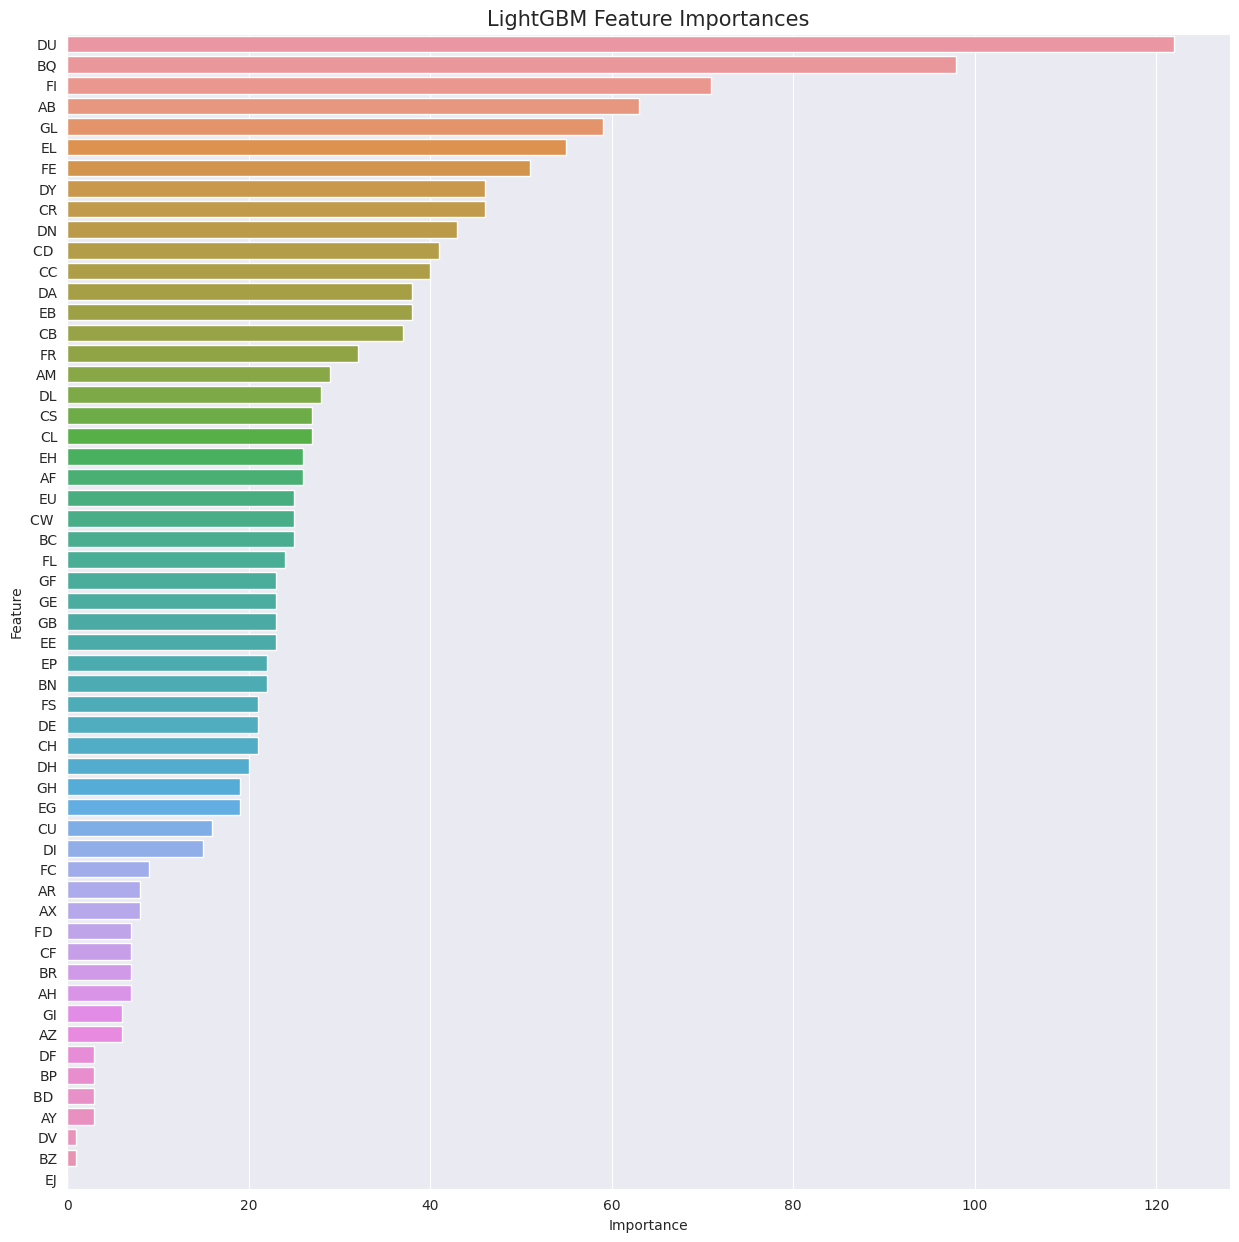

In [19]:
importance = pd.DataFrame(sorted(zip(model.feature_importances_, features)), columns=['Importance', 'Feature'])

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 15))

_ = sns.barplot(x="Importance", y="Feature", data=importance.sort_values(by="Importance", ascending=False))
_ = ax.set_title("LightGBM Feature Importances", fontsize=15)

As we can see, many of the features provide lift according to LightGBM. We can run the same test using just the two features as suggested by the P-Value test.

-------> Fold 1 <--------
: AUC ROC = 0.7401960784313726
-------> Fold 2 <--------
: AUC ROC = 0.6374777183600714
-------> Fold 3 <--------
: AUC ROC = 0.68991899189919
-------> Fold 4 <--------
: AUC ROC = 0.6633986928104575
-------> Fold 5 <--------
: AUC ROC = 0.6220821661998133
--> Overall results for out of fold predictions
: AUC ROC = 0.6509859564869387


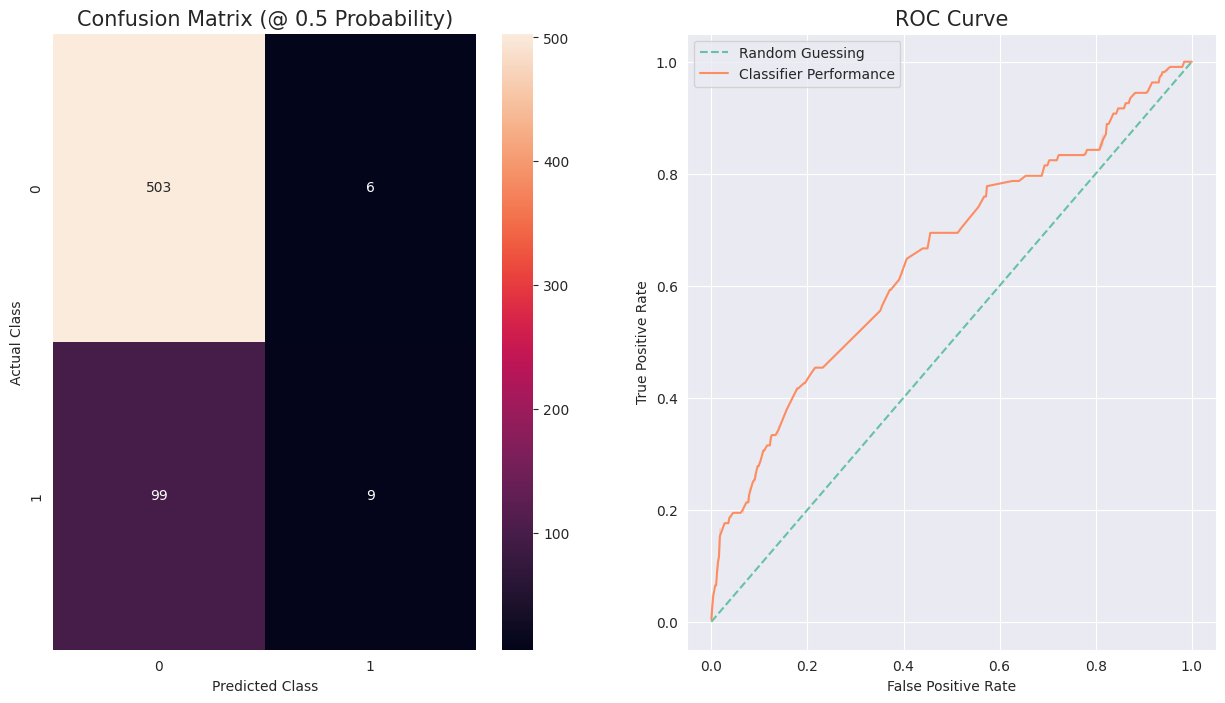

In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

features = [
    'GF', 'FE',
]

train_copy = train.copy()

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, random_state=2023, shuffle=True)
train_oof_preds = np.zeros((train_copy.shape[0],))
train_oof_probas = np.zeros((train_copy.shape[0],))


for fold, (train_index, test_index) in enumerate(skf.split(train_copy, train_copy["Class"])):
    print("-------> Fold {} <--------".format(fold + 1))
    x_train, x_valid = pd.DataFrame(train_copy.iloc[train_index]), pd.DataFrame(train_copy.iloc[test_index])
    y_train, y_valid = train_copy["Class"].iloc[train_index], train_copy["Class"].iloc[test_index]
    
    x_train_features = pd.DataFrame(x_train[features])
    x_valid_features = pd.DataFrame(x_valid[features])

    model = LGBMClassifier(
        random_state=2023,
        objective="binary",
        metric="AUC",
        n_jobs=-1,
        n_estimators=2000,
        verbose=-1,  
        max_depth=3,
    )
    model.fit(
        x_train_features[features], 
        y_train,
        eval_set=[(x_valid_features[features], y_valid)],
        callbacks=[
            early_stopping(50, verbose=False),
            log_evaluation(2000),
        ]
    )
    oof_preds = model.predict(x_valid_features[features])
    oof_probas = model.predict_proba(x_valid_features[features])[:,1]
    train_oof_preds[test_index] = oof_preds
    train_oof_probas[test_index] = oof_probas
    print(": AUC ROC = {}".format(roc_auc_score(y_valid, oof_probas)))
    
auc_vanilla = roc_auc_score(train_copy["Class"], train_oof_probas)
fpr, tpr, _ = roc_curve(train_copy["Class"], train_oof_probas)
print("--> Overall results for out of fold predictions")
print(": AUC ROC = {}".format(auc_vanilla))

confusion = confusion_matrix(train_copy["Class"], train_oof_preds)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

_ = sns.heatmap(confusion, annot=True, fmt=",d", ax=axs[0])
_ = axs[0].set_title("Confusion Matrix (@ 0.5 Probability)", fontsize=15)
_ = axs[0].set_ylabel("Actual Class")
_ = axs[0].set_xlabel("Predicted Class")

_ = sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", label="Random Guessing", ax=axs[1])
_ = sns.lineplot(x=fpr, y=tpr, ax=axs[1], label="Classifier Performance")
_ = axs[1].set_title("ROC Curve", fontsize=15)
_ = axs[1].set_xlabel("False Positive Rate")
_ = axs[1].set_ylabel("True Positive Rate")

From AUC ROC alone, we can see that our model utilizing only the two suggested features from P-Value testing is worse than including all of the available features.

### Key Observations about P-Value Testing

* While P-Value testing suggests that all but 2 features are unnecessary, empirical testing proves this not to be the case.

# 1.7 - Dimensionality Reduction - UMAP

Given we have a large number of features, we may want to explore reducing the dimensionality of the data to see if there is anything interesting. We can use UMAP (Uniform Manifold Approximation and Projection) to reduce the dataset into a fewer number of dimensions. Similar to a PCA, UMAP attempts to reduce the dimensionality of a dataset by utilizing manifold learning. It's primary purpose is to help visualize what a dataset looks like. Ideally, this reduction in dimensionality may also be of benefit when it comes to machine learning tasks, in this case, potentially giving rise to a classifier with better performance than one that attempts to use the entire dataset. We can use a UMAP reduction and use the reduced features in a machine learning classifier directly.

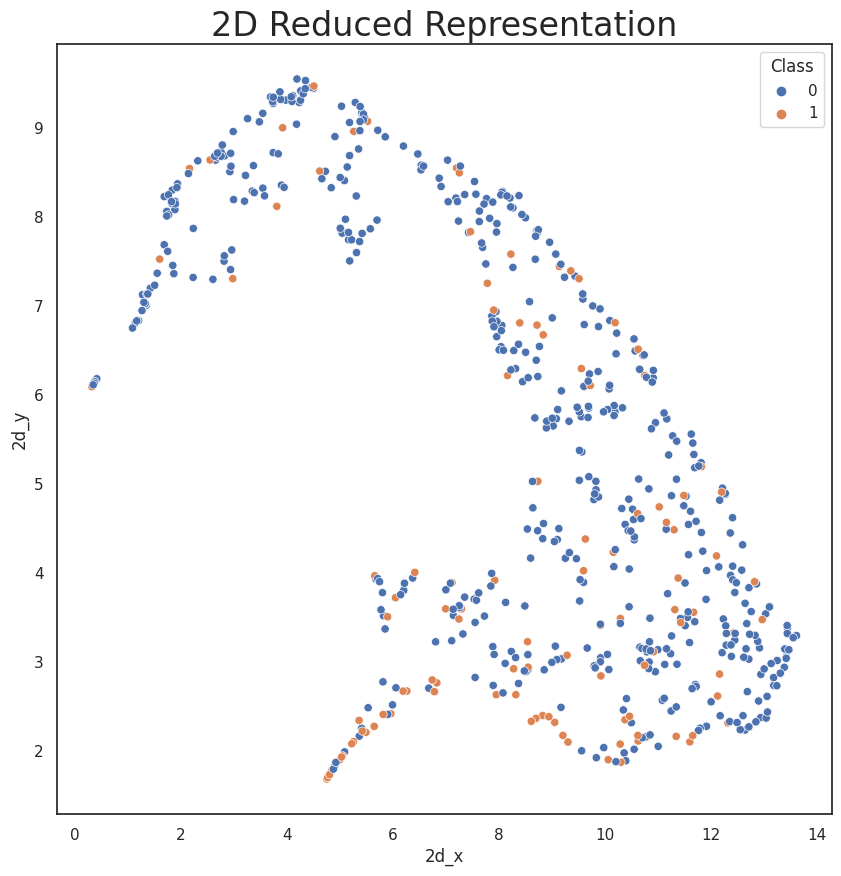

In [21]:
import umap

umap_train = train.copy()
umap_train.fillna(0.0, inplace=True)

features = [
    'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
    'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
    'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
    'EB', 'EE', 'EG', 'EH', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
    'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL',
]

reducer = umap.UMAP(random_state=2023)
reduced_data = reducer.fit_transform(umap_train[features])
umap_train["2d_x"] = reduced_data[:, 0]
umap_train["2d_y"] = reduced_data[:, 1]

sns.set(style='white', context='notebook')

f, ax = plt.subplots(figsize=(10, 10))

_ = sns.scatterplot(data=umap_train, x="2d_x", y="2d_y", hue="Class", ax=ax)
_ = ax.set_title('2D Reduced Representation', fontsize=24)

What we are looking for in the above representation are unique clusters or pockets where it becomes very easy to pick out examples of class 0 and 1. While there appear to be some limited areas of interest, the data appear to be mixed, meaning that it is difficult to separate at a lower dimensionality.

### Key Observations about UMAP

* Dimensionality reduction with UMAP is unlikely to provide significant lift.

# 2 - Feature Exploration

_In progress..._

# 3 - Model Comparisons

_In progress..._

# 4 - Conclusions

* Dataset sizes are small in both memory and on disk, meaning a wide variety of tools are possible within the 16 GB RAM limitations on the Kaggle VMs.
* The supplied `test` dataset does not contain meaningful data since this is a code competition.
    * The actual `test` dataset will remain hidden until notebook submission.
* The `train` dataset contains 617 rows, making this competition challenging from an overfit perspective.
    * Most features appear to be continuous in nature.
    * The `EJ` feature is a binary categorical.
    * The `BN` and `DV` features may be categorical features that have been target encoded.
* The `greeks` dataset, while only provided for training data, may provide opportunities to improve classifier performance through soft labels.
    * The `Id` values in the dataset correspond to those in `train`.
    * There are 4 categorical feature columns, and 1 date column.
* The target classes are imbalanced:
    * 82.5% of the data falls under Class 0, while 17.5% of the data falls under Class 1
    * The supplemental data is similarly skewed, with:
        * 82.5% of the data under `A`
        * 9.89% of the data under `B`
        * 4.70% of the data under `G`
        * 2.92% of the data under `D` 
* There are null values in the training data, impacting roughly 11% of the training samples:
    * Null values appear to be primarily in the `BQ` and `EL` features, either singularly, or together at the same time.
* There are no duplicated rows in the training data.
* Many of the features have outliers that exist several standard deviations from the mean. These outliers either need to be normalized or otherwise exploited.
* No single feature is strongly correlated with the `Class` target.